<a href="https://colab.research.google.com/github/nehemienakashenyi0-afk/N-H-MIE-NAKASHENYI-/blob/main/quatri%C3%A8me_groupe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ÉCOLE DES MINES.
L2 GÉNIE MINIER .

Projet 5: Détection des anomalies dans des capteurs miniers.
effectué par le quatrième groupe :
NÉHÉMIE NAKASHENYI.
BULONZA BIRINGANINE.
DÉLICE CHAMUTU .

In [ ]:
DATA_PATH = None

La variable `DATA_PATH` est initialisée pour être utilisée dans le notebook. La cellule suivante gérera l'upload et l'extraction de l'archive ZIP.

In [ ]:
import zipfile
from google.colab import files
import os
import re

# Check if DATA_PATH is already set (e.g., from Google Drive mount)
if DATA_PATH is None:
    print("📂 Base de données introuvable localement ou sur Google Drive.")
    print("➡️ Veuillez sélectionner le fichier 'archives.zip'.")

    uploaded = files.upload()

    if len(uploaded) == 0:
        raise FileNotFoundError("Aucun fichier n'a été sélectionné.")

    zip_filename = list(uploaded.keys())[0]

    # Normalize the filename to remove potential Colab-added suffixes like '(1)'
    # Example: 'archives (1).zip' -> 'archives.zip'
    normalized_zip_filename = re.sub(r' \(\d+\)\.zip$', '.zip', zip_filename.lower())

    # Verify if the uploaded file is 'archives.zip'
    if normalized_zip_filename != "archives.zip":
        raise ValueError("Le fichier sélectionné doit être 'archives.zip'.")

    # Define the path for the extracted .txt file
    expected_txt_filename = 'household_power_consumption.txt'
    extracted_txt_path = f"/content/{expected_txt_filename}"

    # Unzip the file
    try:
        with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
            # Extract only the desired file
            if expected_txt_filename in zip_ref.namelist():
                zip_ref.extract(expected_txt_filename, path='/content/')
                DATA_PATH = extracted_txt_path
                print(f"✅ Fichier '{expected_txt_filename}' extrait et DATA_PATH défini : {DATA_PATH}")
            else:
                raise FileNotFoundError(f"Le fichier '{expected_txt_filename}' n'a pas été trouvé dans '{zip_filename}'.")
    except zipfile.BadZipFile:
        raise ValueError("Le fichier téléchargé n'est pas une archive ZIP valide.")
    except Exception as e:
        raise Exception(f"Une erreur est survenue lors de l'extraction : {e}")
else:
    print(f"DATA_PATH est déjà défini sur : {DATA_PATH}")

📂 Base de données introuvable localement ou sur Google Drive.
➡️ Veuillez sélectionner le fichier 'archives.zip'.


Saving archives.zip to archives (2).zip
✅ Fichier 'household_power_consumption.txt' extrait et DATA_PATH défini : /content/household_power_consumption.txt


In [ ]:
# =============================================================================
# CELLULE 1 : Installation des bibliothèques (si nécessaire)
# ACTION : Vérifie et installe les packages manquants
# =============================================================================
# !pip install tensorflow scikit-learn pandas numpy matplotlib seaborn --quiet
print("Bibliothèques prêtes !")

Bibliothèques prêtes !


In [ ]:
# =============================================================================
# CELLULE 2 : Importations
# ACTION : Charge toutes les bibliothèques Python nécessaires
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors, KNeighborsClassifier

import tensorflow as tf
from tensorflow import keras
from keras.models import Model
from keras.layers import Input, Dense
from keras.callbacks import EarlyStopping

from google.colab import drive

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
print("Imports OK — TensorFlow :", tf.__version__)

Imports OK — TensorFlow : 2.20.0


chargement des données

### Problème : `NameError` pour `DATA_PATH`

La cellule suivante (`7aIDVEejJoQm`) renvoie une `NameError` car la variable `DATA_PATH` n'est pas définie.

**Solution :**

`DATA_PATH` doit être défini par la cellule d'importation des données (cellule `cdf97c14` juste au-dessus).

**Veuillez vous assurer d'avoir exécuté la cellule `cdf97c14` et d'avoir correctement téléchargé le fichier `archives.zip` lorsque vous y avez été invité.**

Une fois que `archives.zip` est téléchargé et que le fichier `household_power_consumption.txt` en a été extrait, la variable `DATA_PATH` sera définie et la cellule `7aIDVEejJoQm` pourra s'exécuter sans erreur.

In [ ]:
df = pd.read_csv(
DATA_PATH,
    sep=';',
    parse_dates={'DateTime': ['Date', 'Time']},
    dayfirst=True,
    na_values=['?', 'nan', 'NaN', ''],
    low_memory=False
)

In [ ]:
# =============================================================================
# CELLULE 4 : Aperçu et statistiques descriptives
# ACTION : Affiche les premières lignes, types et statistiques du dataset
# =============================================================================
print("=== APERÇU ===")
print(df.head())

print("\n=== TYPES ===")
print(df.dtypes)

print("\n=== STATISTIQUES ===")
print(df.describe())

numeric_cols = ['Global_active_power', 'Global_reactive_power',
                'Voltage', 'Global_intensity',
                'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

=== APERÇU ===
             DateTime  Global_active_power  Global_reactive_power  Voltage  \
0 2006-12-16 17:24:00                4.216                  0.418   234.84   
1 2006-12-16 17:25:00                5.360                  0.436   233.63   
2 2006-12-16 17:26:00                5.374                  0.498   233.29   
3 2006-12-16 17:27:00                5.388                  0.502   233.74   
4 2006-12-16 17:28:00                3.666                  0.528   235.68   

   Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  
0              18.4             0.0             1.0            17.0  
1              23.0             0.0             1.0            16.0  
2              23.0             0.0             2.0            17.0  
3              23.0             0.0             1.0            17.0  
4              15.8             0.0             1.0            17.0  

=== TYPES ===
DateTime                 datetime64[ns]
Global_active_power             float64
G

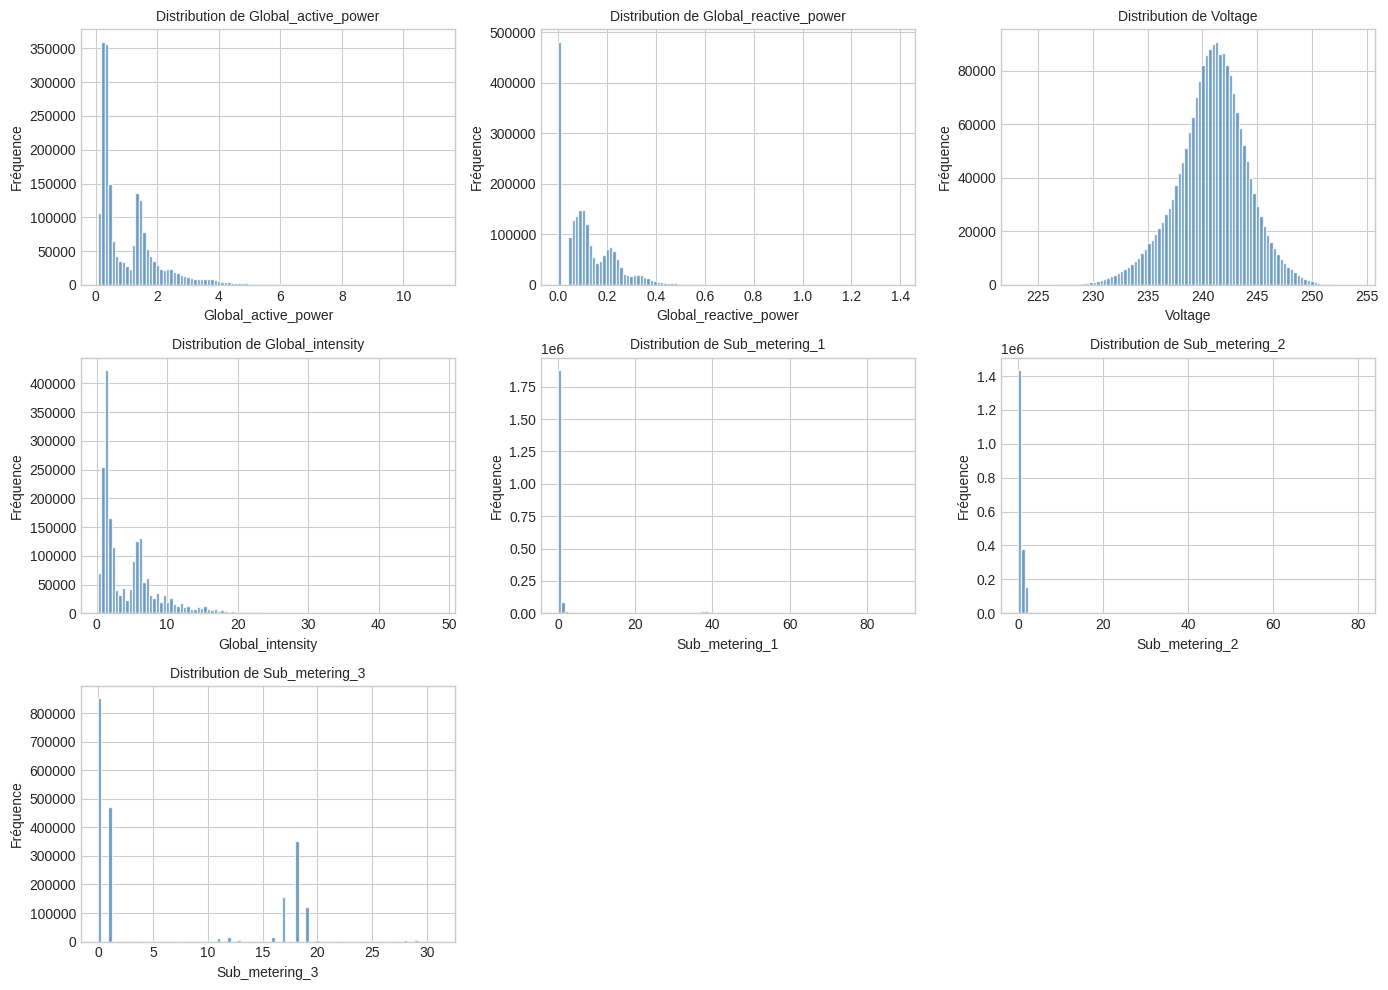

Graphique 'distributions.png' sauvegardé.


In [ ]:
# =============================================================================
# CELLULE 5 : Distributions (Graphique 1)
# ACTION : Trace les histogrammes des 7 variables numériques
# SORTIE : distributions.png
# =============================================================================
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    data_clean = df[col].dropna()
    axes[i].hist(data_clean, bins=100, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'Distribution de {col}', fontsize=10)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Fréquence')

axes[-1].remove()
axes[-2].remove()
plt.tight_layout()
plt.savefig('distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique 'distributions.png' sauvegardé.")

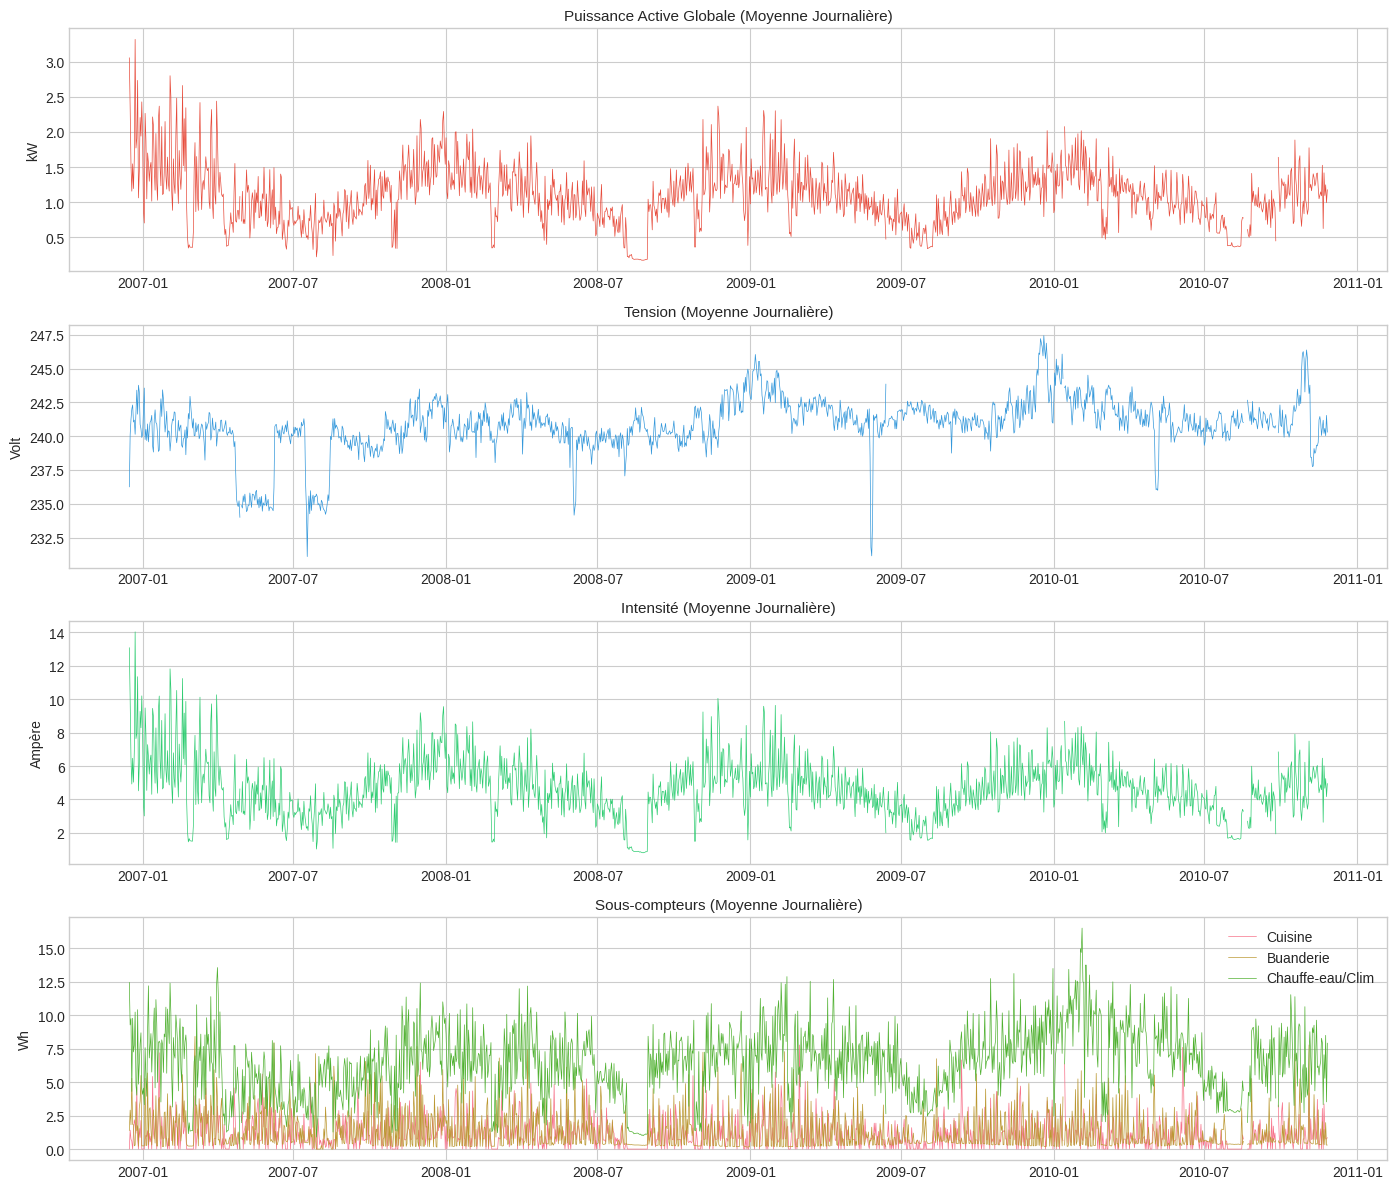

Graphique 'series_temporelles.png' sauvegardé.


In [ ]:
# =============================================================================
# CELLULE 6 : Séries temporelles journalières (Graphique 2)
# ACTION : Visualise l'évolution temporelle des variables (moyenne journalière)
# SORTIE : series_temporelles.png
# =============================================================================
df_daily = df.set_index('DateTime').resample('D').mean()

fig, axes = plt.subplots(4, 1, figsize=(14, 12))

axes[0].plot(df_daily.index, df_daily['Global_active_power'], color='#e74c3c', linewidth=0.5)
axes[0].set_title('Puissance Active Globale (Moyenne Journalière)', fontsize=11)
axes[0].set_ylabel('kW')

axes[1].plot(df_daily.index, df_daily['Voltage'], color='#3498db', linewidth=0.5)
axes[1].set_title('Tension (Moyenne Journalière)', fontsize=11)
axes[1].set_ylabel('Volt')

axes[2].plot(df_daily.index, df_daily['Global_intensity'], color='#2ecc71', linewidth=0.5)
axes[2].set_title('Intensité (Moyenne Journalière)', fontsize=11)
axes[2].set_ylabel('Ampère')

axes[3].plot(df_daily.index, df_daily['Sub_metering_1'], label='Cuisine', linewidth=0.5)
axes[3].plot(df_daily.index, df_daily['Sub_metering_2'], label='Buanderie', linewidth=0.5)
axes[3].plot(df_daily.index, df_daily['Sub_metering_3'], label='Chauffe-eau/Clim', linewidth=0.5)
axes[3].set_title('Sous-compteurs (Moyenne Journalière)', fontsize=11)
axes[3].set_ylabel('Wh')
axes[3].legend()

plt.tight_layout()
plt.savefig('series_temporelles.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique 'series_temporelles.png' sauvegardé.")

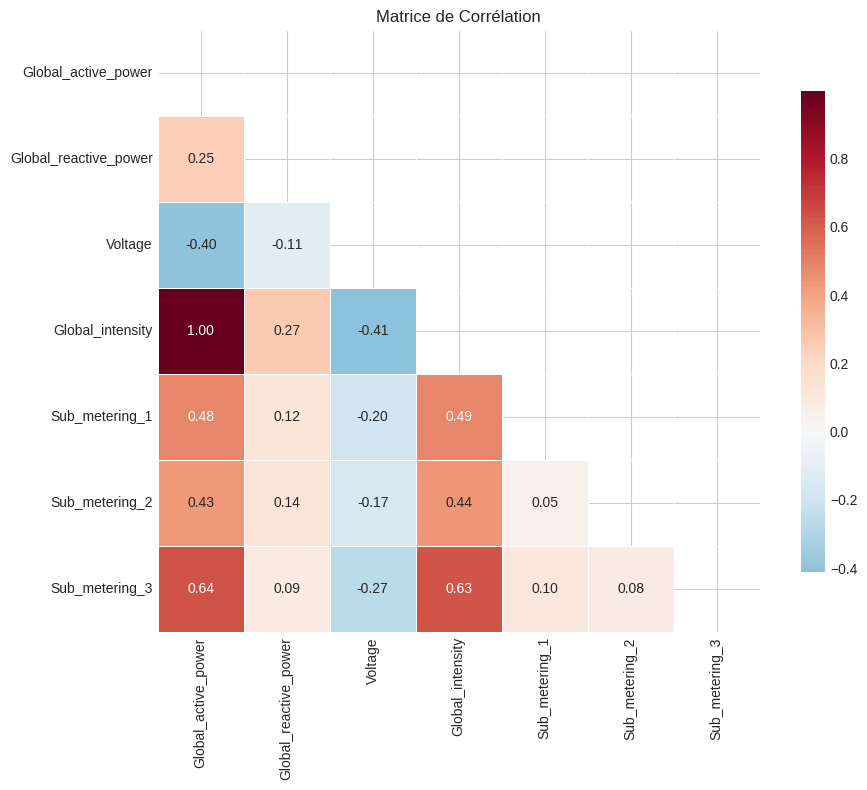

Graphique 'correlation_matrix.png' sauvegardé.


In [ ]:
# =============================================================================
# CELLULE 7 : Matrice de corrélation (Graphique 3)
# ACTION : Affiche la heatmap des corrélations entre variables
# SORTIE : correlation_matrix.png
# =============================================================================
plt.figure(figsize=(10, 8))
corr_matrix = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Matrice de Corrélation', fontsize=12)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique 'correlation_matrix.png' sauvegardé.")

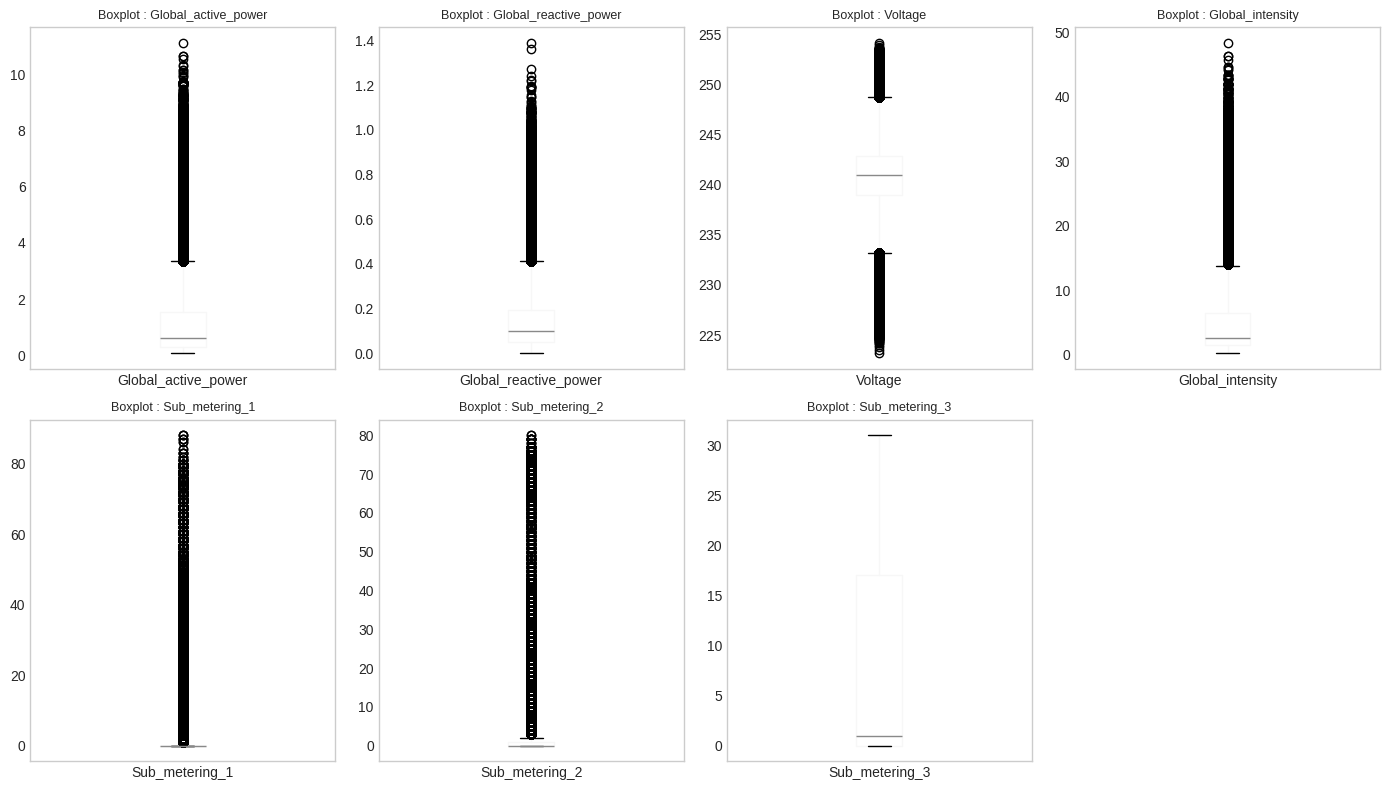

Graphique 'boxplots.png' sauvegardé.


In [ ]:
# =============================================================================
# CELLULE 8 : Boxplots (Graphique 4)
# ACTION : Détecte visuellement les outliers via des boxplots
# SORTIE : boxplots.png
# =============================================================================
fig, axes = plt.subplots(2, 4, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df.boxplot(column=col, ax=axes[i], grid=False)
    axes[i].set_title(f'Boxplot : {col}', fontsize=9)
    axes[i].set_xlabel('')

axes[-1].remove()
plt.tight_layout()
plt.savefig('boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique 'boxplots.png' sauvegardé.")

In [ ]:
# =============================================================================
# CELLULE 9 : Nettoyage des données
# ACTION : Supprime les lignes avec valeurs manquantes (~1.25%)
# =============================================================================
print(f"Avant suppression : {df.shape[0]:,} lignes")
df_clean = df.dropna().copy()
print(f"Après suppression : {df_clean.shape[0]:,} lignes")
print(f"Lignes supprimées : {df.shape[0] - df_clean.shape[0]:,} ({((df.shape[0]-df_clean.shape[0])/df.shape[0]*100):.2f}%)")

df_clean = df_clean.reset_index(drop=True)
print("Dataset nettoyé !")

Avant suppression : 2,075,259 lignes
Après suppression : 2,049,280 lignes
Lignes supprimées : 25,979 (1.25%)
Dataset nettoyé !


In [ ]:
# =============================================================================
# CELLULE 10 : Feature Engineering
# ACTION : Crée 9 nouvelles features (temporelles + physiques)
# =============================================================================
df_features = df_clean.copy()

# Features temporelles
df_features['Hour'] = df_features['DateTime'].dt.hour
df_features['DayOfWeek'] = df_features['DateTime'].dt.dayofweek
df_features['Month'] = df_features['DateTime'].dt.month
df_features['IsWeekend'] = (df_features['DayOfWeek'] >= 5).astype(int)

# Features physiques
df_features['Apparent_power'] = np.sqrt(
    df_features['Global_active_power']**2 + df_features['Global_reactive_power']**2
)
df_features['Power_factor'] = df_features['Global_active_power'] / (df_features['Apparent_power'] + 1e-9)
df_features['Total_sub_metering'] = (
    df_features['Sub_metering_1'] + df_features['Sub_metering_2'] + df_features['Sub_metering_3']
)
df_features['Unmetered_consumption'] = (
    df_features['Global_active_power'] * 1000 / 60 - df_features['Total_sub_metering']
)
df_features['Submetering_ratio'] = (
    df_features['Total_sub_metering'] / (df_features['Global_active_power'] * 1000 / 60 + 1e-9)
)

feature_cols = [
    'Global_active_power', 'Global_reactive_power', 'Voltage',
    'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3',
    'Hour', 'DayOfWeek', 'Month', 'IsWeekend',
    'Apparent_power', 'Power_factor', 'Total_sub_metering',
    'Unmetered_consumption', 'Submetering_ratio'
]

print(f"Features créées : {len(feature_cols)}")
print(df_features[feature_cols].describe().round(4))

Features créées : 16
       Global_active_power  Global_reactive_power       Voltage  \
count         2.049280e+06           2.049280e+06  2.049280e+06   
mean          1.091600e+00           1.237000e-01  2.408399e+02   
std           1.057300e+00           1.127000e-01  3.240000e+00   
min           7.600000e-02           0.000000e+00  2.232000e+02   
25%           3.080000e-01           4.800000e-02  2.389900e+02   
50%           6.020000e-01           1.000000e-01  2.410100e+02   
75%           1.528000e+00           1.940000e-01  2.428900e+02   
max           1.112200e+01           1.390000e+00  2.541500e+02   

       Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  \
count      2.049280e+06    2.049280e+06    2.049280e+06    2.049280e+06   
mean       4.627800e+00    1.121900e+00    1.298500e+00    6.458400e+00   
std        4.444400e+00    6.153000e+00    5.822000e+00    8.437200e+00   
min        2.000000e-01    0.000000e+00    0.000000e+00    0.000000e+00   


Données normalisées : (2049280, 16)
Moyenne : -0.000000 | Écart-type : 1.000000

PCA — PC1 : 37.24% | PC2 : 11.51%
Variance totale : 48.75%


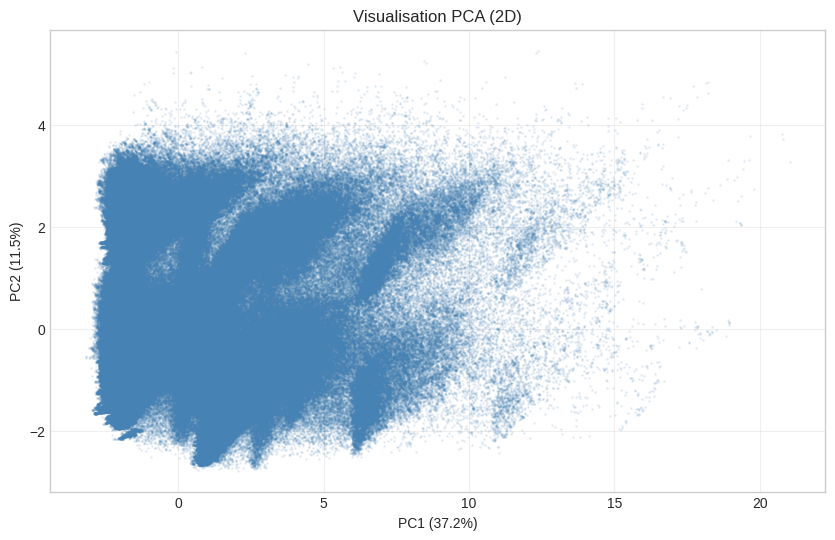

Graphique 'pca_visualization.png' sauvegardé.


In [ ]:
# =============================================================================
# CELLULE 11 : Normalisation + PCA
# ACTION : Standardise les features et réduit en 2D pour visualisation
# SORTIE : pca_visualization.png
# =============================================================================
X = df_features[feature_cols].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)

print(f"Données normalisées : {X_scaled.shape}")
print(f"Moyenne : {X_scaled.mean():.6f} | Écart-type : {X_scaled.std():.6f}")

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"\nPCA — PC1 : {pca.explained_variance_ratio_[0]:.2%} | PC2 : {pca.explained_variance_ratio_[1]:.2%}")
print(f"Variance totale : {sum(pca.explained_variance_ratio_):.2%}")

plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.1, s=1, c='steelblue')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('Visualisation PCA (2D)')
plt.grid(True, alpha=0.3)
plt.savefig('pca_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique 'pca_visualization.png' sauvegardé.")

In [ ]:
# =============================================================================
# CELLULE 12 : Modèle 1 — Isolation Forest
# ACTION : Entraîne Isolation Forest pour détecter les anomalies
# =============================================================================
print("=" * 60)
print("MODÈLE 1 : ISOLATION FOREST")
print("=" * 60)

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.02,
    max_samples='auto',
    random_state=42,
    max_features=1.0,
    bootstrap=False,
    n_jobs=-1,
    verbose=1
)

iso_forest.fit(X_scaled)
predictions_if = iso_forest.predict(X_scaled)
anomaly_scores_if = iso_forest.decision_function(X_scaled)

df_features['IF_Anomaly'] = predictions_if
df_features['IF_Score'] = anomaly_scores_if

n_anomalies_if = (predictions_if == -1).sum()
print(f"\nAnomalies IF : {n_anomalies_if:,} ({n_anomalies_if/len(predictions_if)*100:.2f}%)")
print(f"Score moyen anomalies : {anomaly_scores_if[predictions_if==-1].mean():.4f}")
print(f"Score moyen normaux : {anomaly_scores_if[predictions_if==1].mean():.4f}")

MODÈLE 1 : ISOLATION FOREST


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    4.4s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    4.4s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:   17.3s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:   17.4s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    3.7s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:   16.2s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:   16.3s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    4.4s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:   17.1s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:   17.2s finished



Anomalies IF : 40,986 (2.00%)
Score moyen anomalies : -0.0338
Score moyen normaux : 0.1723


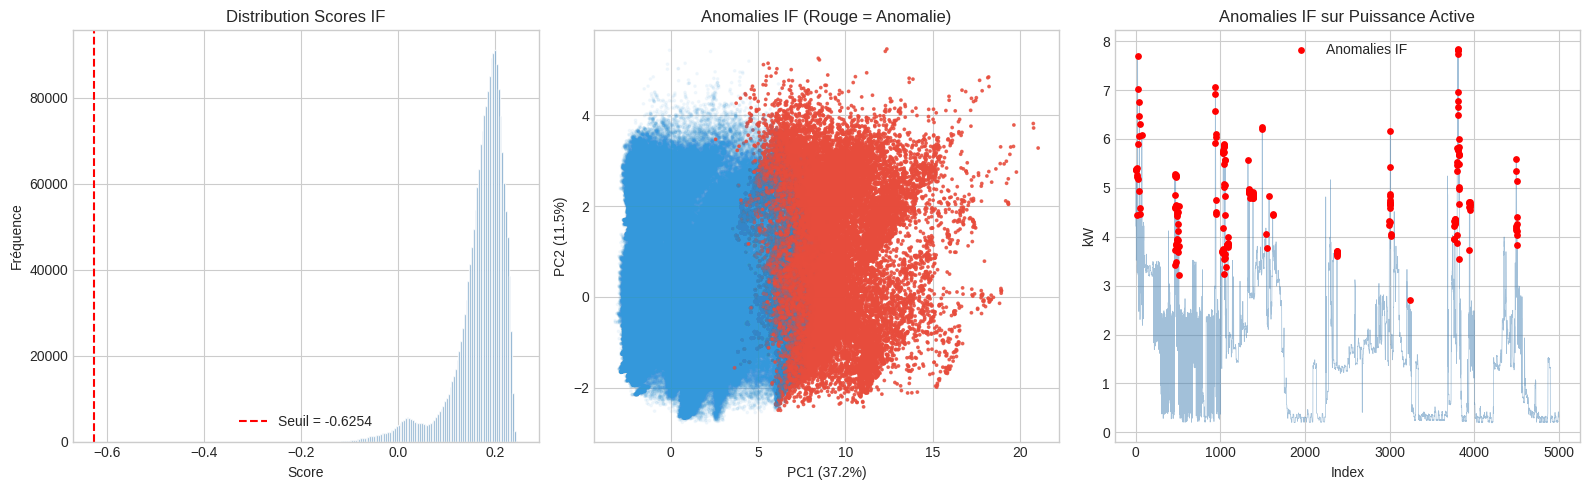

Graphique 'isolation_forest_results.png' sauvegardé.


In [ ]:
# =============================================================================
# CELLULE 13 : Visualisation Isolation Forest (Graphique 5)
# ACTION : Affiche les résultats IF (scores, PCA, série temporelle)
# SORTIE : isolation_forest_results.png
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(anomaly_scores_if, bins=100, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(x=iso_forest.offset_, color='red', linestyle='--',
                label=f'Seuil = {iso_forest.offset_:.4f}')
axes[0].set_title('Distribution Scores IF')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Fréquence')
axes[0].legend()

colors_if = ['#e74c3c' if x == -1 else '#3498db' for x in predictions_if]
alpha_if = [0.8 if x == -1 else 0.05 for x in predictions_if]
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=colors_if, alpha=alpha_if, s=3)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[1].set_title('Anomalies IF (Rouge = Anomalie)')

sample_idx = np.arange(min(5000, len(df_features)))
axes[2].plot(sample_idx, df_features['Global_active_power'].iloc[sample_idx],
             color='steelblue', alpha=0.5, linewidth=0.5)
anom_idx = sample_idx[predictions_if[:len(sample_idx)] == -1]
anom_vals = df_features['Global_active_power'].iloc[anom_idx]
axes[2].scatter(anom_idx, anom_vals, color='red', s=15, zorder=5, label='Anomalies IF')
axes[2].set_title('Anomalies IF sur Puissance Active')
axes[2].set_xlabel('Index')
axes[2].set_ylabel('kW')
axes[2].legend()

plt.tight_layout()
plt.savefig('isolation_forest_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique 'isolation_forest_results.png' sauvegardé.")

In [ ]:
# =============================================================================
# CELLULE 14 : Top 10 anomalies IF
# ACTION : Affiche les 10 anomalies les plus sévères détectées par IF
# =============================================================================
print("TOP 10 ANOMALIES IF (les plus sévères):")
top_if = df_features.nsmallest(10, 'IF_Score')[
    ['DateTime', 'Global_active_power', 'Voltage', 'Global_intensity',
     'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'IF_Score']
]
print(top_if.to_string())

print("\nComparaison Anomalies vs Normaux (moyennes):")
print(df_features.groupby('IF_Anomaly')[numeric_cols].mean().round(4))

TOP 10 ANOMALIES IF (les plus sévères):
                   DateTime  Global_active_power  Voltage  Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  IF_Score
964213  2008-10-19 01:24:00               10.290   230.90              44.6            35.0            66.0            17.0 -0.122513
96635   2007-02-21 20:05:00                8.974   230.04              39.2            36.0            34.0             0.0 -0.121801
1622601 2010-01-24 12:06:00                8.828   232.15              38.4            55.0            37.0            26.0 -0.121145
531875  2007-12-23 19:34:00                8.634   231.96              37.2            36.0            36.0            17.0 -0.120861
96632   2007-02-21 20:02:00                8.246   230.40              36.2            36.0            34.0             0.0 -0.120790
964212  2008-10-19 01:23:00                9.134   232.59              39.4            36.0            43.0            17.0 -0.120691
964216  2008-10-19 01:

In [ ]:
# =============================================================================
# CELLULE 15 : Modèle 2 — Construction Autoencodeur
# ACTION : Définit l'architecture du réseau de neurones (16→12→8→4→8→12→16)
# =============================================================================
print("=" * 60)
print("MODÈLE 2 : AUTOENCODEUR")
print("=" * 60)

input_dim = X_scaled.shape[1]

input_layer = Input(shape=(input_dim,), name='Input')
encoded = Dense(12, activation='relu', name='Encoder_1')(input_layer)
encoded = Dense(8, activation='relu', name='Encoder_2')(encoded)
bottleneck = Dense(4, activation='relu', name='Bottleneck')(encoded)
decoded = Dense(8, activation='relu', name='Decoder_1')(bottleneck)
decoded = Dense(12, activation='relu', name='Decoder_2')(decoded)
output_layer = Dense(input_dim, activation='linear', name='Output')(decoded)

autoencoder = Model(inputs=input_layer, outputs=output_layer, name='Autoencoder_Anomaly')
autoencoder.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

autoencoder.summary()

MODÈLE 2 : AUTOENCODEUR


Model: "Autoencoder_Anomaly"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder_1 (Dense)               │ (None, 12)             │           204 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder_2 (Dense)               │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Bottleneck (Dense)              │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder_1 (Dense)               │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder_2 (Dense)               │ (None, 12)             │           108 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 16)             │           208 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 700 (2.73 KB)

 Trainable params: 700 (2.73 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# =============================================================================
# CELLULE 16 : Entraînement Autoencodeur
# ACTION : Entraîne l'autoencodeur avec early stopping sur 30 epochs max
# =============================================================================
print("Entraînement en cours...")

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

history = autoencoder.fit(
    X_scaled, X_scaled,
    epochs=30,
    batch_size=512,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

print(f"\nEntraînement terminé ! Epochs : {len(history.history['loss'])}")
print(f"Perte finale train : {history.history['loss'][-1]:.6f}")
print(f"Perte finale val : {history.history['val_loss'][-1]:.6f}")

Entraînement en cours...
Epoch 1/30
3603/3603 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.1114 - mae: 0.1986 - val_loss: 0.1079 - val_mae: 0.1959
Epoch 2/30
3603/3603 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.1110 - mae: 0.1994 - val_loss: 0.1081 - val_mae: 0.1973
Epoch 3/30
3603/3603 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.1105 - mae: 0.2003 - val_loss: 0.1073 - val_mae: 0.1972
Epoch 4/30
3603/3603 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.1100 - mae: 0.2009 - val_loss: 0.1080 - val_mae: 0.1977
Epoch 5/30
3603/3603 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.1094 - mae: 0.2014 - val_loss: 0.1076 - val_mae: 0.2005
Epoch 6/30
3603/3603 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 0.1085 - mae: 0.2011 - val_loss: 0.1080 - val_mae: 0.2010
Epoch 7/30
3603/3603 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.1071 - mae: 0.1997 - val_loss: 0.1079 - val_mae: 0.2013
Epoch 8/30
3603/3603 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.1061 - mae: 0.1979 - val_loss: 0.1075 - val_mae: 0.1988
Epoch 8: 

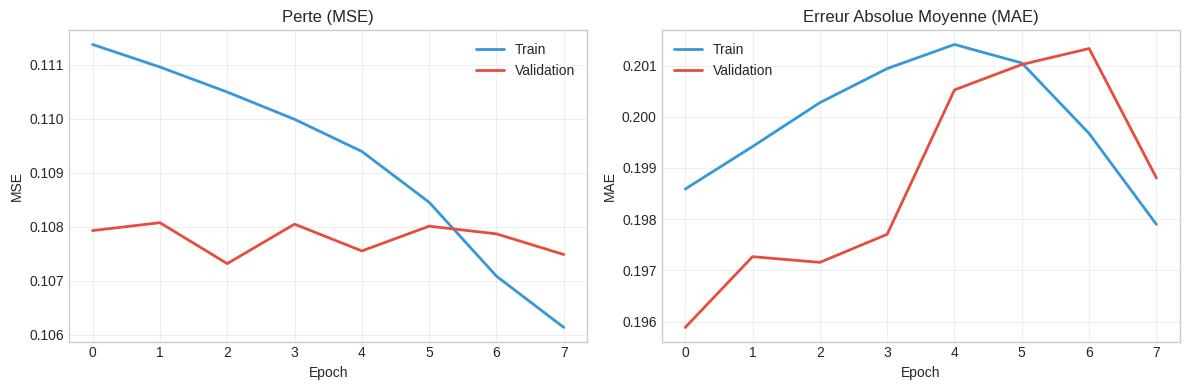

Graphique 'autoencoder_training.png' sauvegardé.


In [ ]:
# =============================================================================
# CELLULE 17 : Courbes d'entraînement (Graphique 6)
# ACTION : Visualise l'évolution de la perte et de l'erreur absolue
# SORTIE : autoencoder_training.png
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='Train', color='#3498db', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation', color='#e74c3c', linewidth=2)
axes[0].set_title('Perte (MSE)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['mae'], label='Train', color='#3498db', linewidth=2)
axes[1].plot(history.history['val_mae'], label='Validation', color='#e74c3c', linewidth=2)
axes[1].set_title('Erreur Absolue Moyenne (MAE)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('autoencoder_training.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique 'autoencoder_training.png' sauvegardé.")

In [ ]:
# =============================================================================
# CELLULE 18 : Détection Autoencodeur
# ACTION : Calcule l'erreur de reconstruction et détecte anomalies (seuil P98)
# =============================================================================
print("=" * 60)
print("DÉTECTION AUTOENCODEUR")
print("=" * 60)

X_reconstructed = autoencoder.predict(X_scaled, batch_size=1024, verbose=1)
mse = np.mean(np.power(X_scaled - X_reconstructed, 2), axis=1)

df_features['AE_Reconstruction_Error'] = mse
THRESHOLD_PERCENTILE = 98
threshold_ae = np.percentile(mse, THRESHOLD_PERCENTILE)
df_features['AE_Anomaly'] = (mse > threshold_ae).astype(int)
df_features['AE_Anomaly_Label'] = np.where(df_features['AE_Anomaly'] == 1, -1, 1)

n_anomalies_ae = df_features['AE_Anomaly'].sum()
print(f"\nSeuil (P{THRESHOLD_PERCENTILE}) : {threshold_ae:.6f}")
print(f"Anomalies AE : {n_anomalies_ae:,} ({n_anomalies_ae/len(df_features)*100:.2f}%)")

for p in [50, 90, 95, 98, 99, 99.5]:
    print(f"  P{p} : {np.percentile(mse, p):.6f}")

DÉTECTION AUTOENCODEUR
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step

Seuil (P98) : 0.467964
Anomalies AE : 40,986 (2.00%)
  P50 : 0.072161
  P90 : 0.244339
  P95 : 0.335640
  P98 : 0.467964
  P99 : 0.573761
  P99.5 : 0.694204


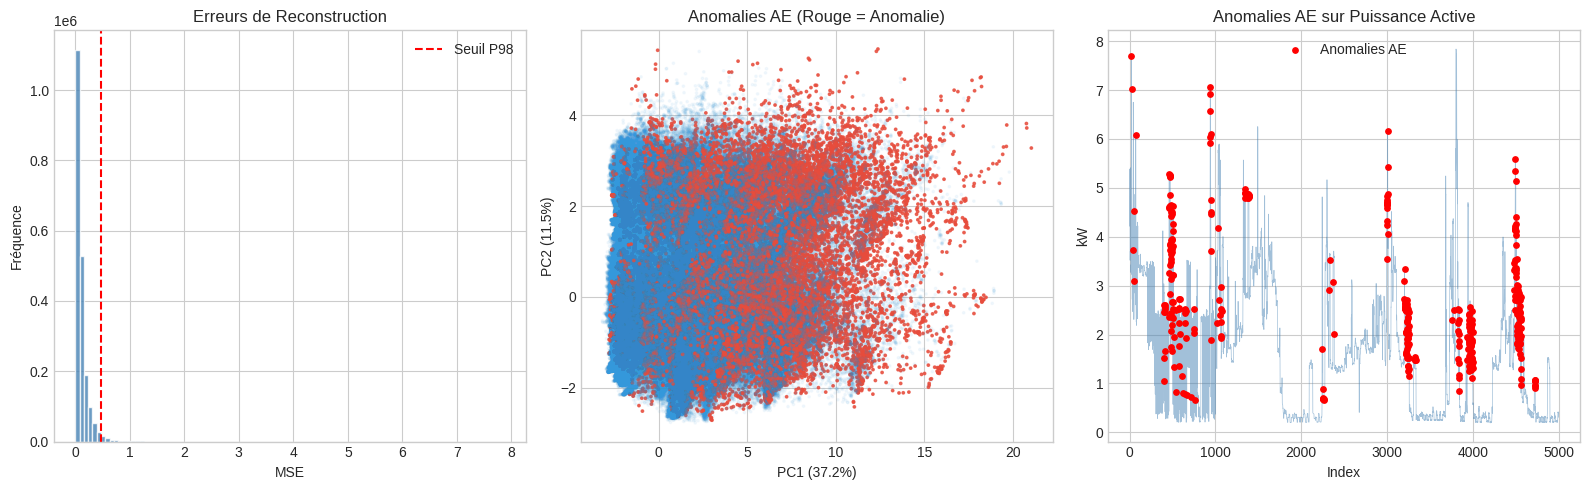

Graphique 'autoencoder_results.png' sauvegardé.


In [ ]:
# =============================================================================
# CELLULE 19 : Visualisation Autoencodeur (Graphique 7)
# ACTION : Affiche les résultats AE (erreurs, PCA, série temporelle)
# SORTIE : autoencoder_results.png
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(mse, bins=100, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(x=threshold_ae, color='red', linestyle='--',
                label=f'Seuil P{THRESHOLD_PERCENTILE}')
axes[0].set_title('Erreurs de Reconstruction')
axes[0].set_xlabel('MSE')
axes[0].set_ylabel('Fréquence')
axes[0].legend()

colors_ae = ['#e74c3c' if x == 1 else '#3498db' for x in df_features['AE_Anomaly']]
alpha_ae = [0.8 if x == 1 else 0.05 for x in df_features['AE_Anomaly']]
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=colors_ae, alpha=alpha_ae, s=3)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[1].set_title('Anomalies AE (Rouge = Anomalie)')

sample_idx = np.arange(min(5000, len(df_features)))
axes[2].plot(sample_idx, df_features['Global_active_power'].iloc[sample_idx],
             color='steelblue', alpha=0.5, linewidth=0.5)
anom_mask = df_features['AE_Anomaly'].iloc[sample_idx] == 1
axes[2].scatter(sample_idx[anom_mask],
                df_features['Global_active_power'].iloc[sample_idx[anom_mask]],
                color='red', s=15, zorder=5, label='Anomalies AE')
axes[2].set_title('Anomalies AE sur Puissance Active')
axes[2].set_xlabel('Index')
axes[2].set_ylabel('kW')
axes[2].legend()

plt.tight_layout()
plt.savefig('autoencoder_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique 'autoencoder_results.png' sauvegardé.")

MODÈLE 3 : DBSCAN — Détermination des paramètres
Échantillon : 50,000 points


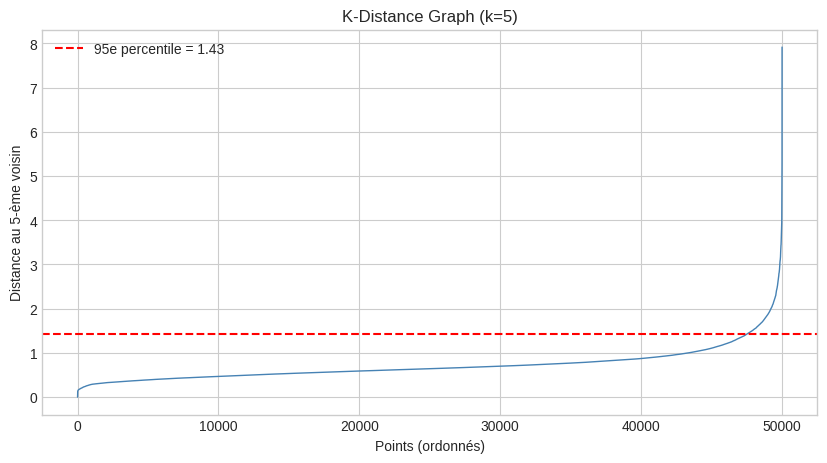


Eps suggéré : 1.4253 | MinPts : 6


In [ ]:
# =============================================================================
# CELLULE 20 : Modèle 3 — DBSCAN (k-distance)
# ACTION : Détermine Eps et MinPts via la méthode du coude sur 50K points
# SORTIE : dbscan_kdistance.png
# =============================================================================
print("=" * 60)
print("MODÈLE 3 : DBSCAN — Détermination des paramètres")
print("=" * 60)

SAMPLE_SIZE = 50000
np.random.seed(42)
sample_idx = np.random.choice(X_scaled.shape[0], size=SAMPLE_SIZE, replace=False)
X_sample = X_scaled[sample_idx]

print(f"Échantillon : {SAMPLE_SIZE:,} points")

k = 5
nbrs = NearestNeighbors(n_neighbors=k, n_jobs=-1)
nbrs.fit(X_sample)
distances, indices = nbrs.kneighbors(X_sample)
k_distances = np.sort(distances[:, k-1])

plt.figure(figsize=(10, 5))
plt.plot(k_distances, color='steelblue', linewidth=1)
plt.xlabel('Points (ordonnés)')
plt.ylabel(f'Distance au {k}-ème voisin')
plt.title(f'K-Distance Graph (k={k})')

elbow_idx = int(len(k_distances) * 0.95)
plt.axhline(y=k_distances[elbow_idx], color='red', linestyle='--',
            label=f'95e percentile = {k_distances[elbow_idx]:.2f}')
plt.legend()
plt.savefig('dbscan_kdistance.png', dpi=150, bbox_inches='tight')
plt.show()

eps_suggested = k_distances[elbow_idx]
print(f"\nEps suggéré : {eps_suggested:.4f} | MinPts : {k+1}")

In [ ]:
# =============================================================================
# CELLULE 21 : Entraînement DBSCAN
# ACTION : Clustering par densité sur l'échantillon de 50K points
# =============================================================================
EPS = max(eps_suggested, 1.5)
MIN_PTS = 6

print(f"DBSCAN — Eps={EPS:.4f}, MinPts={MIN_PTS}")
dbscan = DBSCAN(eps=EPS, min_samples=MIN_PTS, metric='euclidean', n_jobs=-1)
dbscan_labels = dbscan.fit_predict(X_sample)

n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"Clusters : {n_clusters} | Bruit (anomalies) : {n_noise:,} ({n_noise/SAMPLE_SIZE*100:.2f}%)")

DBSCAN — Eps=1.5000, MinPts=6
Clusters : 27 | Bruit (anomalies) : 1,542 (3.08%)


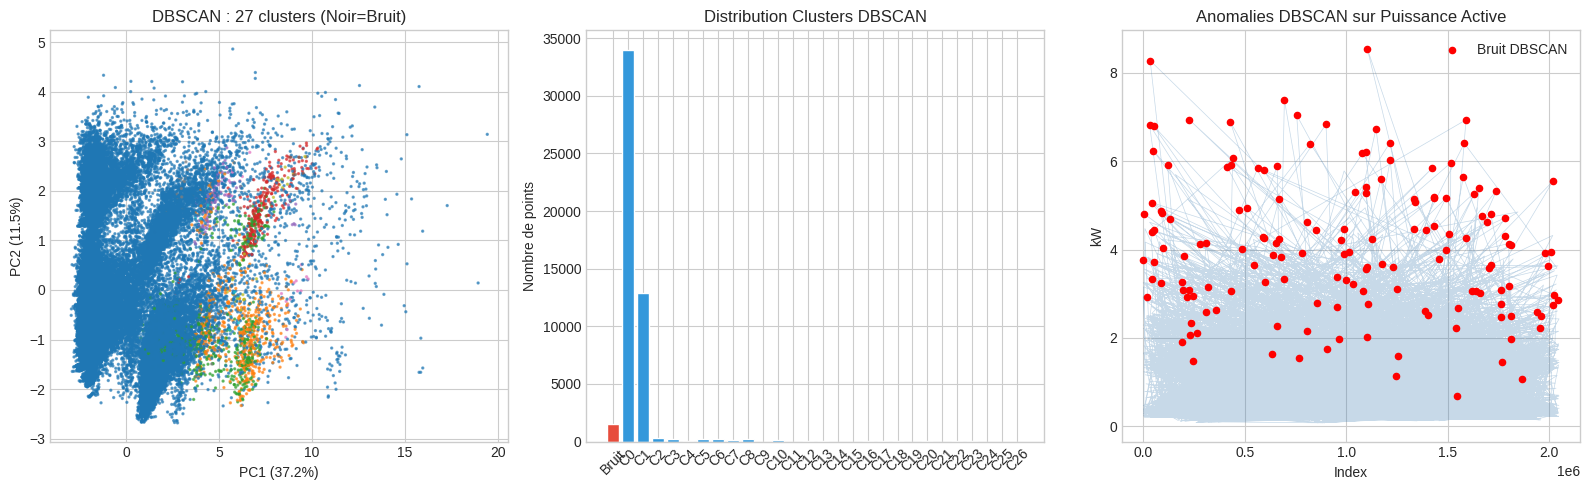

Graphique 'dbscan_results.png' sauvegardé.


In [ ]:
# =============================================================================
# CELLULE 22 : Visualisation DBSCAN (Graphique 8)
# ACTION : Affiche les clusters DBSCAN en PCA, distribution et temporel
# SORTIE : dbscan_results.png
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

scatter = axes[0].scatter(X_pca[sample_idx, 0], X_pca[sample_idx, 1],
                          c=dbscan_labels, cmap='tab10', s=2, alpha=0.6)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[0].set_title(f'DBSCAN : {n_clusters} clusters (Noir=Bruit)')

labels_unique, labels_counts = np.unique(dbscan_labels, return_counts=True)
colors = ['#e74c3c' if l == -1 else '#3498db' for l in labels_unique]
axes[1].bar(range(len(labels_unique)), labels_counts, color=colors, edgecolor='white')
axes[1].set_xticks(range(len(labels_unique)))
axes[1].set_xticklabels([f'Bruit' if l == -1 else f'C{l}' for l in labels_unique], rotation=45)
axes[1].set_title('Distribution Clusters DBSCAN')
axes[1].set_ylabel('Nombre de points')

sample_positions = sample_idx[:min(5000, len(sample_idx))]
sample_labels = dbscan_labels[:len(sample_positions)]
axes[2].plot(sample_positions,
             df_features['Global_active_power'].iloc[sample_positions],
             color='steelblue', alpha=0.3, linewidth=0.5)
noise_mask = sample_labels == -1
axes[2].scatter(sample_positions[noise_mask],
                df_features['Global_active_power'].iloc[sample_positions[noise_mask]],
                color='red', s=20, zorder=5, label='Bruit DBSCAN')
axes[2].set_title('Anomalies DBSCAN sur Puissance Active')
axes[2].set_xlabel('Index')
axes[2].set_ylabel('kW')
axes[2].legend()

plt.tight_layout()
plt.savefig('dbscan_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique 'dbscan_results.png' sauvegardé.")

In [ ]:
# =============================================================================
# CELLULE 23 : Propagation DBSCAN à tout le dataset
# ACTION : Étend les labels DBSCAN à l'ensemble via k-NN
# =============================================================================
print("Propagation des labels DBSCAN...")

train_labels = dbscan_labels[dbscan_labels != -1]
train_data = X_sample[dbscan_labels != -1]

knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn.fit(train_data, train_labels)

batch_size = 50000
all_labels_dbscan = np.full(X_scaled.shape[0], -1)

for i in range(0, X_scaled.shape[0], batch_size):
    end = min(i + batch_size, X_scaled.shape[0])
    all_labels_dbscan[i:end] = knn.predict(X_scaled[i:end])

df_features['DBSCAN_Label'] = all_labels_dbscan
df_features['DBSCAN_Anomaly'] = (all_labels_dbscan == -1).astype(int)
df_features['DBSCAN_Anomaly_Label'] = np.where(all_labels_dbscan == -1, -1, 1)

n_anomalies_dbscan = (all_labels_dbscan == -1).sum()
print(f"Anomalies DBSCAN (complet) : {n_anomalies_dbscan:,} ({n_anomalies_dbscan/len(df_features)*100:.2f}%)")

Propagation des labels DBSCAN...
Anomalies DBSCAN (complet) : 0 (0.00%)


In [ ]:
# =============================================================================
# CELLULE 24 : Tableau comparatif
# ACTION : Compare les 3 modèles (nombre d'anomalies, pourcentage)
# =============================================================================
print("=" * 60)
print("COMPARAISON DES 3 MODÈLES")
print("=" * 60)

results = {
    'Modèle': ['Isolation Forest', 'Autoencodeur', 'DBSCAN'],
    'N_anomalies': [
        (df_features['IF_Anomaly'] == -1).sum(),
        df_features['AE_Anomaly'].sum(),
        (df_features['DBSCAN_Anomaly'] == 1).sum()
    ],
    'Pourcentage (%)': [
        (df_features['IF_Anomaly'] == -1).mean() * 100,
        df_features['AE_Anomaly'].mean() * 100,
        (df_features['DBSCAN_Anomaly'] == 1).mean() * 100
    ]
}
results_df = pd.DataFrame(results)
results_df['Pourcentage (%)'] = results_df['Pourcentage (%)'].round(2)
print(results_df.to_string(index=False))

df_features['All_Agree_Anomaly'] = (
    (df_features['IF_Anomaly'] == -1) &
    (df_features['AE_Anomaly'] == 1) &
    (df_features['DBSCAN_Anomaly'] == 1)
).astype(int)

df_features['At_Least_One'] = (
    (df_features['IF_Anomaly'] == -1) |
    (df_features['AE_Anomaly'] == 1) |
    (df_features['DBSCAN_Anomaly'] == 1)
).astype(int)

print(f"\nConsensus (3/3) : {df_features['All_Agree_Anomaly'].sum():,}")
print(f"Union (≥1) : {df_features['At_Least_One'].sum():,}")

COMPARAISON DES 3 MODÈLES
          Modèle  N_anomalies  Pourcentage (%)
Isolation Forest        40986              2.0
    Autoencodeur        40986              2.0
          DBSCAN            0              0.0

Consensus (3/3) : 0
Union (≥1) : 72,504


In [ ]:
# =============================================================================
# CELLULE 25 : Analyse croisée
# ACTION : Calcule les corrélations et intersections entre les 3 modèles
# =============================================================================
if_binary = (df_features['IF_Anomaly'] == -1).astype(int)
ae_binary = df_features['AE_Anomaly'].values
db_binary = df_features['DBSCAN_Anomaly'].values

print("Corrélation entre détections :")
corr_data = pd.DataFrame({'IF': if_binary, 'AE': ae_binary, 'DBSCAN': db_binary})
print(corr_data.corr().round(4))

print(f"\nIF ∩ AE : {((if_binary == 1) & (ae_binary == 1)).sum():,}")
print(f"IF ∩ DBSCAN : {((if_binary == 1) & (db_binary == 1)).sum():,}")
print(f"AE ∩ DBSCAN : {((ae_binary == 1) & (db_binary == 1)).sum():,}")
print(f"IF ∩ AE ∩ DBSCAN : {((if_binary == 1) & (ae_binary == 1) & (db_binary == 1)).sum():,}")

Corrélation entre détections :
            IF      AE  DBSCAN
IF      1.0000  0.2153     NaN
AE      0.2153  1.0000     NaN
DBSCAN     NaN     NaN     NaN

IF ∩ AE : 9,468
IF ∩ DBSCAN : 0
AE ∩ DBSCAN : 0
IF ∩ AE ∩ DBSCAN : 0


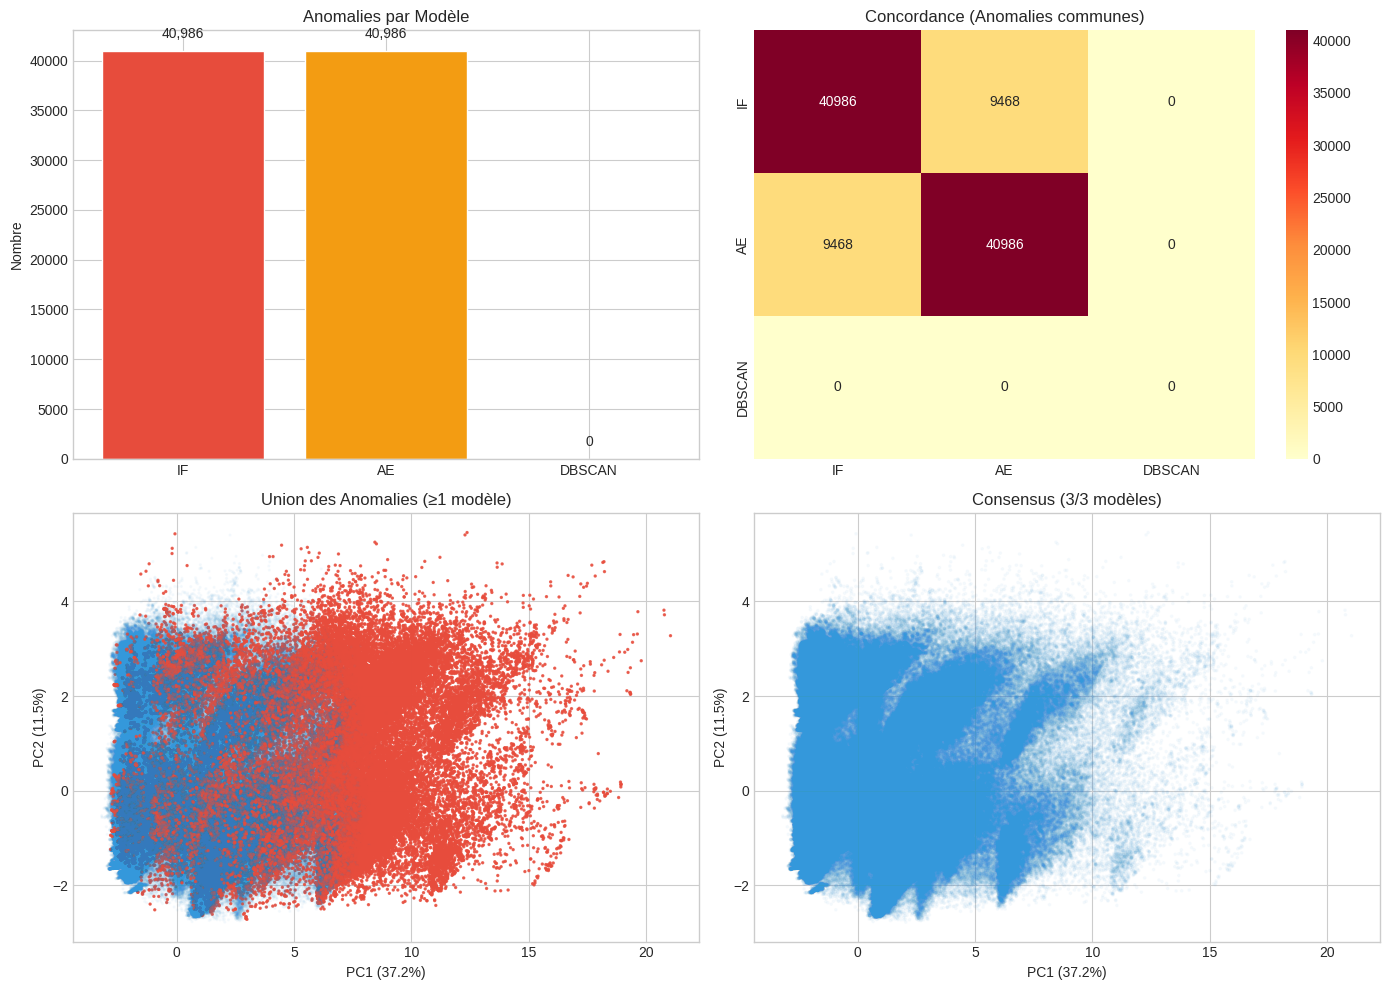

Graphique 'comparaison_modeles.png' sauvegardé.


In [ ]:
# =============================================================================
# CELLULE 26 : Visualisation comparative (Graphique 9)
# ACTION : Compare les 3 modèles (barres, heatmap, union, consensus)
# SORTIE : comparaison_modeles.png
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

models = ['IF', 'AE', 'DBSCAN']
anom_counts = [if_binary.sum(), ae_binary.sum(), db_binary.sum()]
axes[0, 0].bar(models, anom_counts, color=['#e74c3c', '#f39c12', '#9b59b6'], edgecolor='white')
axes[0, 0].set_title('Anomalies par Modèle')
axes[0, 0].set_ylabel('Nombre')
for i, v in enumerate(anom_counts):
    axes[0, 0].text(i, v + 1000, f'{v:,}', ha='center', va='bottom')

concordance = np.zeros((3, 3))
for i, a in enumerate([if_binary, ae_binary, db_binary]):
    for j, b in enumerate([if_binary, ae_binary, db_binary]):
        concordance[i, j] = ((a == 1) & (b == 1)).sum()
sns.heatmap(concordance, annot=True, fmt='.0f', cmap='YlOrRd',
            xticklabels=models, yticklabels=models, ax=axes[0, 1])
axes[0, 1].set_title('Concordance (Anomalies communes)')

union_anomaly = df_features['At_Least_One'].values
colors_union = ['#e74c3c' if x == 1 else '#3498db' for x in union_anomaly]
alpha_union = [0.8 if x == 1 else 0.03 for x in union_anomaly]
axes[1, 0].scatter(X_pca[:, 0], X_pca[:, 1], c=colors_union, alpha=alpha_union, s=2)
axes[1, 0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[1, 0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[1, 0].set_title('Union des Anomalies (≥1 modèle)')

intersection = df_features['All_Agree_Anomaly'].values
colors_inter = ['#e74c3c' if x == 1 else '#3498db' for x in intersection]
alpha_inter = [1.0 if x == 1 else 0.03 for x in intersection]
axes[1, 1].scatter(X_pca[:, 0], X_pca[:, 1], c=colors_inter, alpha=alpha_inter, s=3)
axes[1, 1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[1, 1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[1, 1].set_title('Consensus (3/3 modèles)')

plt.tight_layout()
plt.savefig('comparaison_modeles.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique 'comparaison_modeles.png' sauvegardé.")

In [ ]:
# =============================================================================
# CELLULE 27 : Interprétation physique
# ACTION : Analyse les caractéristiques des anomalies vs normaux
# =============================================================================
numeric_cols_full = numeric_cols + ['Apparent_power', 'Power_factor',
                                     'Total_sub_metering', 'Unmetered_consumption']

print("MOYENNES : ANOMALIES vs NORMAUX")
comparison = pd.DataFrame({
    'Normaux': df_features[df_features['At_Least_One'] == 0][numeric_cols_full].mean(),
    'Anomalies': df_features[df_features['At_Least_One'] == 1][numeric_cols_full].mean()
})
comparison['Écart (%)'] = ((comparison['Anomalies'] - comparison['Normaux']) /
                            comparison['Normaux'] * 100).round(2)
print(comparison.round(4))

print("\n--- TYPES D'ANOMALIES ---")
high_power = df_features[df_features['Global_active_power'] > df_features['Global_active_power'].quantile(0.999)]
print(f"1. Pics de consommation : {len(high_power):,} cas (max: {high_power['Global_active_power'].max():.2f} kW)")

tension_low = df_features[df_features['Voltage'] < df_features['Voltage'].quantile(0.005)]
tension_high = df_features[df_features['Voltage'] > df_features['Voltage'].quantile(0.995)]
print(f"2. Tension anormale : {len(tension_low) + len(tension_high):,} cas")

low_pf = df_features[df_features['Power_factor'] < 0.3]
print(f"3. Faible facteur de puissance : {len(low_pf):,} cas")

unmetered_high = df_features[df_features['Unmetered_consumption'] > df_features['Unmetered_consumption'].quantile(0.995)]
print(f"4. Consommation non mesurée excessive : {len(unmetered_high):,} cas")

df_anomalies = df_features[df_features['At_Least_One'] == 1]
anom_by_hour = df_anomalies.groupby('Hour').size()
peak_hours = anom_by_hour.nlargest(3)
print(f"\nHeures de pic : {', '.join([f'{h}h ({v:,})' for h, v in peak_hours.items()])}")

MOYENNES : ANOMALIES vs NORMAUX
                        Normaux  Anomalies  Écart (%)
Global_active_power      0.9994     3.6067     260.90
Global_reactive_power    0.1201     0.2234      86.08
Voltage                240.9672   237.3684      -1.49
Global_intensity         4.2332    15.3853     263.45
Sub_metering_1           0.6025    15.2825    2436.33
Sub_metering_2           0.8509    13.5037    1487.07
Sub_metering_3           6.3069    10.5893      67.90
Apparent_power           1.0175     3.6201     255.79
Power_factor             0.9627     0.9912       2.96
Total_sub_metering       7.7603    39.3755     407.39
Unmetered_consumption    8.8958    20.7357     133.10

--- TYPES D'ANOMALIES ---
1. Pics de consommation : 2,048 cas (max: 11.12 kW)
2. Tension anormale : 20,382 cas
3. Faible facteur de puissance : 0 cas
4. Consommation non mesurée excessive : 10,217 cas

Heures de pic : 19h (7,282), 20h (6,809), 21h (6,047)


In [ ]:
# =============================================================================
# CELLULE 28 : Téléchargement des graphiques
# ACTION : Liste tous les graphiques générés et propose le téléchargement
# =============================================================================
from google.colab import files

graphiques = [
    'distributions.png', 'series_temporelles.png', 'correlation_matrix.png',
    'boxplots.png', 'pca_visualization.png', 'isolation_forest_results.png',
    'autoencoder_training.png', 'autoencoder_results.png',
    'dbscan_kdistance.png', 'dbscan_results.png', 'comparaison_modeles.png'
]

print("=" * 60)
print("RÉCAPITULATIF DES 11 GRAPHIQUES GÉNÉRÉS")
print("=" * 60)
for i, g in enumerate(graphiques, 1):
    print(f"  {i:2d}. {g}")

print("\nPour télécharger tous les graphiques, décommente les lignes ci-dessous :")
for g in graphiques:
    files.download(g)

print("\n" + "=" * 60)
print("PROJET TERMINÉ — Toutes les cellules ont été exécutées")
print("=" * 60)

RÉCAPITULATIF DES 11 GRAPHIQUES GÉNÉRÉS
   1. distributions.png
   2. series_temporelles.png
   3. correlation_matrix.png
   4. boxplots.png
   5. pca_visualization.png
   6. isolation_forest_results.png
   7. autoencoder_training.png
   8. autoencoder_results.png
   9. dbscan_kdistance.png
  10. dbscan_results.png
  11. comparaison_modeles.png

Pour télécharger tous les graphiques, décommente les lignes ci-dessous :


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


PROJET TERMINÉ — Toutes les cellules ont été exécutées
